In [5]:
import seaborn as sns
import pandas as pd

df = sns.load_dataset('titanic')

df.to_csv('titanic_raw.csv', index=False)

print(df.info())
print(df.isnull().sum())
print(df.head(10))

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB
None
survived         0
pclass           0
sex              0
age            177
sibsp        

In [8]:
print("DATA INSPECTION")

print("\n1. Dataset Overview:")
print(df.info())

print("\n2. Missing Values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
})
print(missing_df[missing_df['Missing Count'] > 0])

print("\n3. Data Types:")
print(df.dtypes)

print("\n4. First 10 Rows:")
print(df.head(10))

print("\n5. Numeric Column Stats:")
print(df.describe())

print("\n6. Categorical Distributions:")
print(f"Survived: {df['survived'].value_counts()}")
print(f"Class: {df['pclass'].value_counts()}")
print(f"Sex: {df['sex'].value_counts()}")
print(f"Embarked: {df['embarked'].value_counts()}")

DATA INSPECTION

1. Dataset Overview:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB
None

2. Missing Values:
             Missing Count  Per

In [23]:
df['age_filled'] = df.groupby('pclass')['age'].transform(
    lambda x: x.fillna(x.median())
)

print("Age missing before:", df['age'].isnull().sum())
print("Age missing after:", df['age_filled'].isnull().sum())

df_clean = df.drop(columns=['deck'])

mode_embarked = df['embarked'].mode()[0]
df['embarked_filled'] = df['embarked'].fillna(mode_embarked)

print(f"Embarked filled with: {mode_embarked}")

print("\nMissing values after cleaning:")
print(df.isnull().sum())

Age missing before: 177
Age missing after: 0
Embarked filled with: S

Missing values after cleaning:
survived             0
pclass               0
sex                  0
age                177
sibsp                0
parch                0
fare                 0
embarked             2
class                0
who                  0
adult_male           0
deck               688
embark_town          2
alive                0
alone                0
age_filled           0
embarked_filled      0
dtype: int64


Fare statistics:
count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: fare, dtype: float64


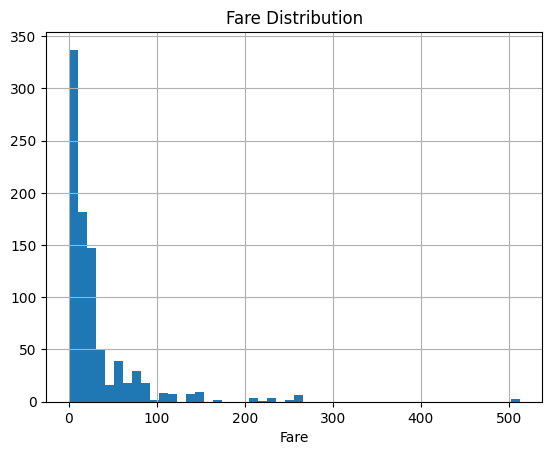


Fare outliers (>$181.28):
     pclass      fare
27        1  263.0000
88        1  263.0000
118       1  247.5208
258       1  512.3292
299       1  247.5208
311       1  262.3750
341       1  263.0000
377       1  211.5000
380       1  227.5250
438       1  263.0000
527       1  221.7792
557       1  227.5250
679       1  512.3292
689       1  211.3375
700       1  227.5250
716       1  227.5250
730       1  211.3375
737       1  512.3292
742       1  262.3750
779       1  211.3375

Age range:
Min: 0.42, Max: 80.0


In [16]:
print("Fare statistics:")
print(df['fare'].describe())

import matplotlib.pyplot as plt
df['fare'].hist(bins=50)
plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.show()

mean_fare = df['fare'].mean()
std_fare = df['fare'].std()
outlier_threshold = mean_fare + (3 * std_fare)

outliers = df[df['fare'] > outlier_threshold]
print(f"\nFare outliers (>${outlier_threshold:.2f}):")
print(outliers[['pclass', 'fare']])


print("\nAge range:")
print(f"Min: {df['age'].min()}, Max: {df['age'].max()}")

In [18]:
# p5

In [22]:
print(f"Duplicate rows: {df.duplicated().sum()}")

df_clean = df.drop_duplicates()

columns_to_keep = [
    'survived', 'pclass', 'sex', 'age_filled', 'sibsp', 'parch',
    'fare', 'embarked_filled', 'alone'
]

df_final = df_clean[columns_to_keep].copy()

df_final.columns = [
    'survived', 'class', 'sex', 'age', 'siblings_spouses',
    'parents_children', 'fare', 'embarked', 'is_alone'
]

df_final.to_csv('titanic_clean.csv', index=False)

print("\n" + "="*50)
print("CLEANING COMPLETE!")
print("="*50)
print(f"Original rows: {len(df)}")
print(f"Clean rows: {len(df_final)}")
print(f"Columns: {len(df_final.columns)}")
print("\nClean dataset saved as 'titanic_clean.csv'")

Duplicate rows: 107

CLEANING COMPLETE!
Original rows: 891
Clean rows: 784
Columns: 9

Clean dataset saved as 'titanic_clean.csv'
